# Real GeoMet and Polymetallic Reports

**Audience:** practitioners who need reproducible, leakage-aware mining case studies.  
**Prerequisite:** run `python -m mineral_process.cli download-data`.  
**Goals:** execute the spatial GeoMet models, execute ordered-holdout recovery baselines and inspect
an observed multiobjective frontier while keeping the two operations strictly separate.

In [1]:
import sys
from pathlib import Path

ROOT = next(
    path
    for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "src" / "mineral_process").exists()
)
sys.path.insert(0, str(ROOT / "src"))

## 1. Verify provenance before modeling

In [2]:
import json

manifest = json.loads((ROOT / "data/raw/provenance.json").read_text(encoding="utf-8"))
[(item["dataset"], item["size_bytes"], item["sha256"][:12]) for item in manifest["files"]]

[('geomet', 362226, 'e0636576be0a'),
 ('geomet', 25239, '972ebf9ebb2e'),
 ('geomet', 17531, 'e7968c250c1c'),
 ('polymetallic', 229838, '7468e1a29dae'),
 ('iron_flotation', 53386037, 'fa1fb0c928d8')]

## 2. GeoMet: chemistry and coordinates with a held-out spatial block

In [3]:
import pandas as pd

from mineral_process.case_studies import run_geomet_case

geomet_summary = run_geomet_case(ROOT / "reports/generated/geomet", seed=42)
pd.DataFrame(geomet_summary["targets"]).T

,mae,rmse,r2,train_rows,test_rows,held_out_spatial_block
comminution_M,0.125576,0.133325,0.553798,56.0,4.0,3.0
comminution_A,11.080972,16.161241,0.280480,56.0,4.0,3.0
flotation_LCT,0.038470,0.041882,0.449698,45.0,7.0,7.0


The upstream column names `M` and `A` are intentionally preserved. The project does not claim they are BWI/DWT fields without an authoritative dictionary.

## 3. Polymetallic grinding: operational-only features and ordered holdout

In [4]:
from mineral_process.case_studies import run_polymetallic_case

poly_summary = run_polymetallic_case(ROOT / "reports/generated/polymetallic", seed=42)
pd.DataFrame(poly_summary["targets"]).T

C:\Users\Yuri_\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] O sistema não pode encontrar o arquivo especificado
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\Yuri_\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\Yuri_\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Yuri_\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, clo

,mae,rmse,r2,train_rows,test_rows
Rec_total_Ag,2.026643,2.987203,-0.525587,552.0,139.0
Rec_Cu_ConCu,7.376619,9.202304,-0.095526,552.0,139.0
Rec_Pb_ConPb,5.739686,7.609952,-0.629155,552.0,139.0
Rec_Zn_ConZn,3.018652,3.771103,-0.438911,552.0,139.0


<Axes: title={'center': 'Observed non-dominated rows (descriptive, not causal)'}, xlabel='P80_12x16', ylabel='Rec_total_Ag'>

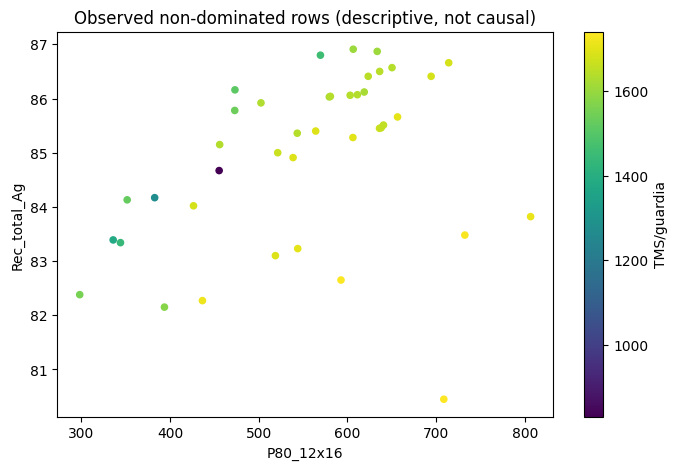

In [5]:
pareto = pd.read_csv(ROOT / "reports/generated/polymetallic/observed_pareto.csv")
pareto.plot.scatter(
    x="P80_12x16",
    y="Rec_total_Ag",
    c="TMS/guardia",
    colormap="viridis",
    figsize=(8, 5),
    title="Observed non-dominated rows (descriptive, not causal)",
)

## Exercise

Compare each model's RMSE with the target standard deviation. Which target is most useful despite a
negative R²? Explain why a random split would not repair a regime-shift problem.

In [6]:
# Answer scaffold: join metrics to raw target dispersion.
from mineral_process.data.loaders import load_polymetallic

raw = load_polymetallic(ROOT / "data/raw/polymetallic")["Matriz_datos"]
comparison = pd.DataFrame(poly_summary["targets"]).T
comparison["target_std"] = [raw.loc[:, target].std() for target in comparison.index]
comparison["rmse_over_std"] = comparison["rmse"] / comparison["target_std"]
comparison[["rmse", "target_std", "rmse_over_std", "r2"]]

,rmse,target_std,rmse_over_std,r2
Rec_total_Ag,2.987203,1.883852,1.585689,-0.525587
Rec_Cu_ConCu,9.202304,9.470538,0.971677,-0.095526
Rec_Pb_ConPb,7.609952,6.712036,1.133777,-0.629155
Rec_Zn_ConZn,3.771103,3.626896,1.039760,-0.438911


## Pitfall and extension

**Pitfall:** interpreting the observed Pareto rows as recommended interventions. These are
associations in an observational table. **Extension:** use documented timestamps/batches and ore
domains to build grouped or rolling validation, then test interventions only in the digital twin or
a controlled campaign.